In [1]:
import zipfile
import io
import os
import numpy as np
import numpy.random as random
import scipy as sp
import pandas as pd
from pandas import Series, DataFrame

# Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
%matplotlib inline

# Display up to three decimal places
%precision 3

'%.3f'

In [14]:
web_traffic = pd.read_csv("../data/web_traffic.csv")
customers = pd.read_csv("../data/customers.csv")
orders = pd.read_csv("../data/orders.csv")
order_item = pd.read_csv("../data/order_items.csv")
shipments = pd.read_csv("../data/shipments.csv")
reviews = pd.read_csv("../data/reviews.csv")
promotions = pd.read_csv("../data/promotions.csv")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28260\4022678476.py:4: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_item = pd.read_csv("../data/order_items.csv")


In [ ]:
web_traffic.head(10)
web_traffic['traffic_source'].value_counts()


traffic_source
organic_search    1090
paid_search        784
social_media       632
email_campaign     505
referral           375
direct             266
Name: count, dtype: int64

In [ ]:
promotions.isnull().sum()
promotions.fillna("ALL", axis = 1)

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,ALL,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,ALL,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,ALL,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,ALL,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000
5,PROMO-0006,Rural Special 2013,percentage,15.0,2013-01-31,2013-03-01,Outdoor,in_store,0,0
6,PROMO-0007,Spring Sale 2014,percentage,12.0,2014-03-18,2014-04-17,ALL,email,1,0
7,PROMO-0008,Mid-Year Sale 2014,percentage,18.0,2014-06-23,2014-07-22,ALL,social_media,0,0
8,PROMO-0009,Fall Launch 2014,percentage,10.0,2014-08-30,2014-10-01,ALL,all_channels,0,100000
9,PROMO-0010,Year-End Sale 2014,percentage,20.0,2014-11-19,2015-01-02,ALL,all_channels,0,100000


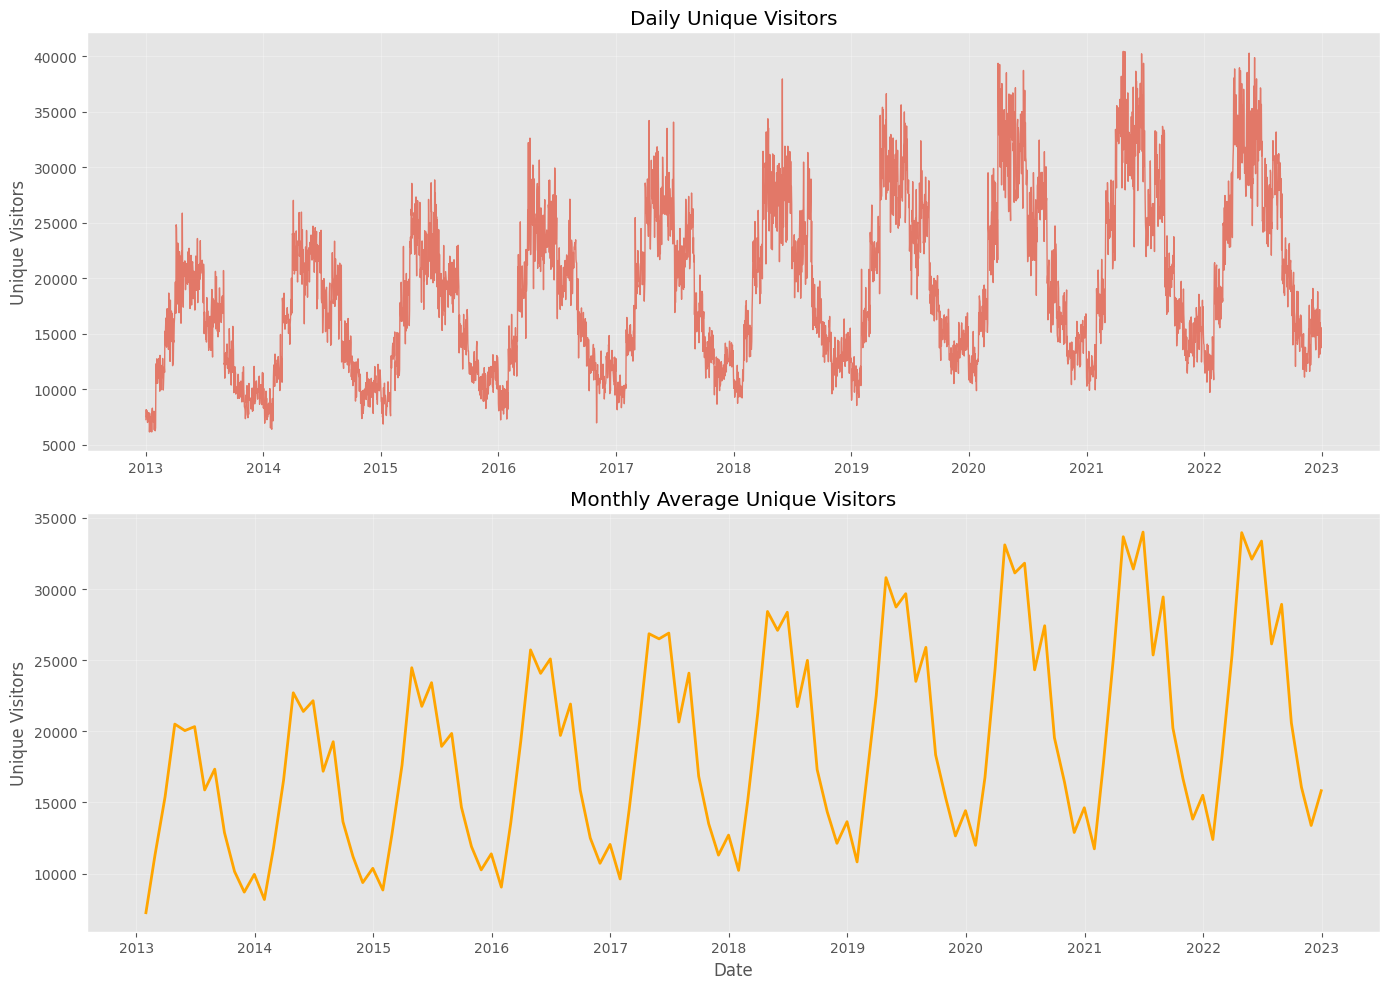

In [ ]:
# Resample to monthly average
monthly_avg = web_traffic.set_index('date')['unique_visitors'].resample('ME').mean()
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Daily data
axes[0].plot(web_traffic['date'], web_traffic['unique_visitors'], linewidth=1, alpha=0.7, label='Daily')
axes[0].set_title('Daily Unique Visitors')
axes[0].set_ylabel('Unique Visitors')
axes[0].grid(True, alpha=0.3)

# Monthly average
axes[1].plot(monthly_avg.index, monthly_avg.values, linewidth=2, color='orange', label='Monthly Avg')
axes[1].set_title('Monthly Average Unique Visitors')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Unique Visitors')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
customers.head(10)

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search
5,6,15202,Phu Ly,2022-04-14,Female,25-34,organic_search
6,8,15202,Phu Ly,2015-09-11,Male,45-54,social_media
7,9,15202,Phu Ly,2020-02-14,Male,35-44,email_campaign
8,10,15202,Phu Ly,2014-03-03,Male,25-34,organic_search
9,11,15203,Viet Tri,2017-11-07,Male,35-44,organic_search


In [23]:
customers['acquisition_channel'].value_counts()

acquisition_channel
organic_search    36450
social_media      24448
paid_search       24285
email_campaign    14674
referral          12270
direct             9803
Name: count, dtype: int64

In [24]:
customers['age_group'].value_counts()

age_group
25-34    36342
35-44    31920
45-54    23172
18-24    17039
55+      13457
Name: count, dtype: int64